In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)
sns.set_style('whitegrid')

In [3]:
df=pd.read_csv('Cardiotocographic.csv')

In [4]:
df.shape

(2126, 14)

In [6]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [7]:
# Step 3: basic info
print("Columns:", list(df.columns))
print("\nData types:")
display(df.dtypes)

print("\nMissing values (count):")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())


Columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']

Data types:


LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


Missing values (count):


LB          21
DS          21
MLTV        21
Width       21
Tendency    21
DP          21
NSP         21
AC          20
FM           0
UC           0
DL           0
ALTV         0
ASTV         0
MSTV         0
dtype: int64


Duplicate rows: 2


In [8]:
# Step 4: normalize column names (keeps readability)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('\n','_')
print("Cleaned column names:")
print(list(df.columns))


Cleaned column names:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']


In [9]:
# Step 5: attempt to convert columns to numeric where appropriate
converted = []
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        # remove commas and stray non-numeric characters (but keep minus and dot)
        s = df[col].astype(str).str.replace(r'[^0-9\.\-]', '', regex=True)
        coerced = pd.to_numeric(s, errors='coerce')
        frac = coerced.notnull().mean()
        if frac >= 0.5:  # majority convertible -> convert
            df[col] = coerced
            converted.append((col, frac))
print("Converted columns (col, fraction_converted):")
display(pd.DataFrame(converted, columns=['column','fraction_converted']))
print("\nDtypes after conversion:")
display(df.dtypes)


Converted columns (col, fraction_converted):


,column,fraction_converted



Dtypes after conversion:


LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [10]:
# Step 6: missing values strategy
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
display(pd.DataFrame({'missing_percent': missing_pct}))

# flag columns with >40% missing
cols_flag = missing_pct[missing_pct > 40].index.tolist()
if cols_flag:
    print("Columns with >40% missing (review/drop):", cols_flag)
else:
    print("No columns with >40% missing.")

# Impute numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        med = df[c].median()
        df[c].fillna(med, inplace=True)
        print(f"Imputed numeric '{c}' with median = {med}")

# Impute object/categorical columns with mode
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode()
        if not mode.empty:
            df[c].fillna(mode[0], inplace=True)
            print(f"Imputed categorical '{c}' with mode = {mode[0]}")
        else:
            df[c].fillna('Unknown', inplace=True)
            print(f"Filled categorical '{c}' with 'Unknown'")

print("\nMissing values after imputation:")
display(df.isnull().sum().sort_values(ascending=False))


,missing_percent
LB,0.987770
DS,0.987770
MLTV,0.987770
Width,0.987770
Tendency,0.987770
DP,0.987770
NSP,0.987770
AC,0.940734
FM,0.000000
UC,0.000000


No columns with >40% missing.
Imputed numeric 'LB' with median = 133.0
Imputed numeric 'AC' with median = 0.001633991
Imputed numeric 'DS' with median = 0.0
Imputed numeric 'DP' with median = 0.0
Imputed numeric 'MLTV' with median = 7.4
Imputed numeric 'Width' with median = 67.0
Imputed numeric 'Tendency' with median = 0.0
Imputed numeric 'NSP' with median = 1.0

Missing values after imputation:


C:\Users\INDIAN\AppData\Local\Temp\ipykernel_3368\1978282385.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(med, inplace=True)


LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [11]:
# Step 7: duplicates - show then drop
n_dup = df.duplicated().sum()
print("Duplicate rows found:", n_dup)
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates. New shape:", df.shape)


Duplicate rows found: 2
Dropped duplicates. New shape: (2124, 14)


In [12]:
# Step 8: descriptive summary for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
summary = pd.DataFrame(index=num_cols)
summary['count'] = df[num_cols].count()
summary['mean'] = df[num_cols].mean()
summary['median'] = df[num_cols].median()
summary['std'] = df[num_cols].std()
summary['min'] = df[num_cols].min()
summary['q1'] = df[num_cols].quantile(0.25)
summary['q3'] = df[num_cols].quantile(0.75)
summary['iqr'] = summary['q3'] - summary['q1']
summary['max'] = df[num_cols].max()
summary['skew'] = df[num_cols].skew()
summary['n_unique'] = df[num_cols].nunique()
display(summary.T)

# Quick notable stats
print("\nTop 5 most variable columns (std):")
display(summary['std'].sort_values(ascending=False).head(5))


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000
mean,133.338641,0.003205,0.009904,0.004394,0.001897,0.000002,0.000174,47.012459,1.364345,10.295650,8.271840,70.426833,0.313541,1.301783
median,133.000000,0.001634,0.000000,0.004486,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
std,11.212447,0.004374,0.067571,0.003340,0.003344,0.000141,0.000836,18.812403,1.174084,21.212676,7.736910,42.728278,0.643417,0.642369
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
q1,126.000000,0.000000,0.000000,0.001858,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
q3,140.000000,0.005612,0.002568,0.006536,0.003292,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
iqr,14.000000,0.005612,0.002568,0.004678,0.003292,0.000000,0.000000,29.000000,1.000000,11.000000,6.200000,63.000000,1.000000,0.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000
skew,0.323569,2.032003,6.749691,0.973685,2.008927,8.457283,6.453124,0.054887,4.141709,2.979526,3.563587,0.498480,-0.485275,1.825387



Top 5 most variable columns (std):


Width    42.728278
ALTV     21.212676
ASTV     18.812403
LB       11.212447
MLTV      7.736910
Name: std, dtype: float64

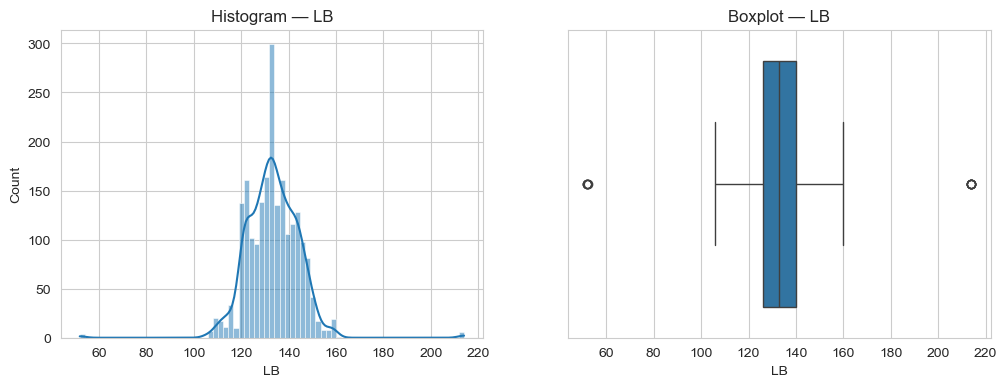

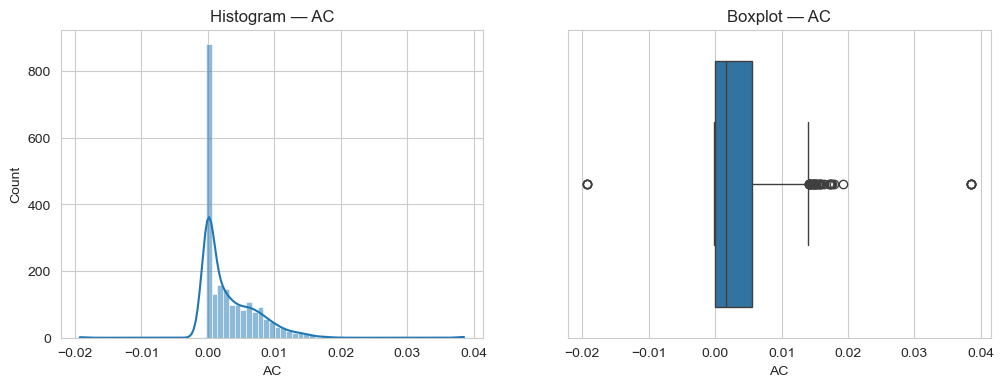

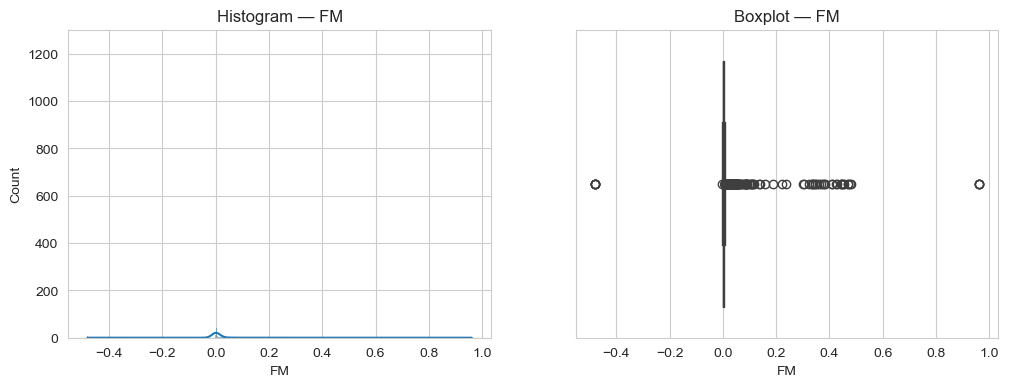

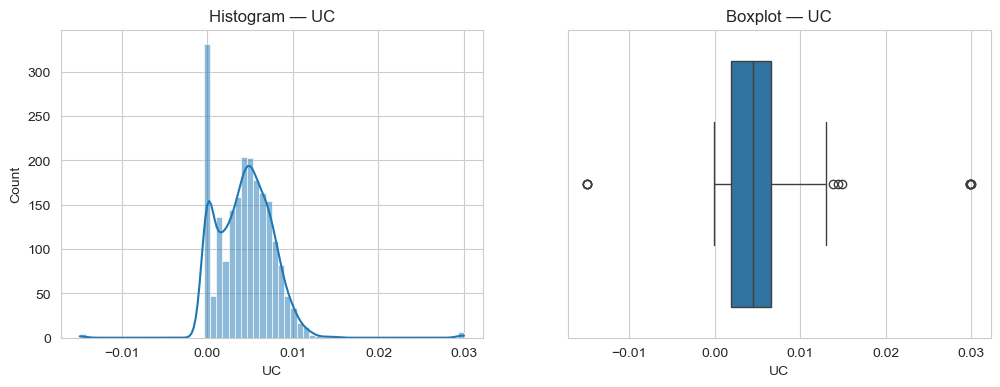

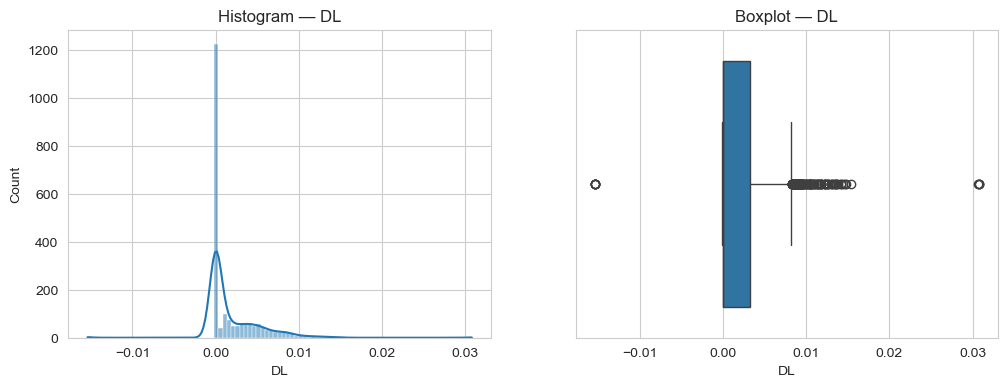

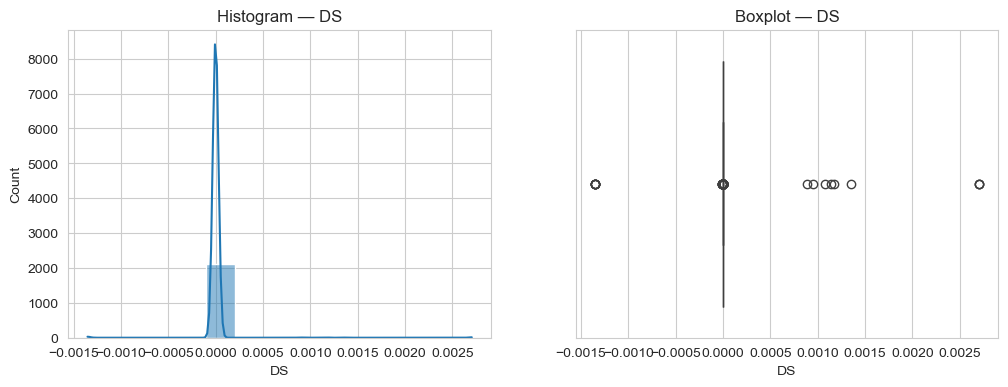

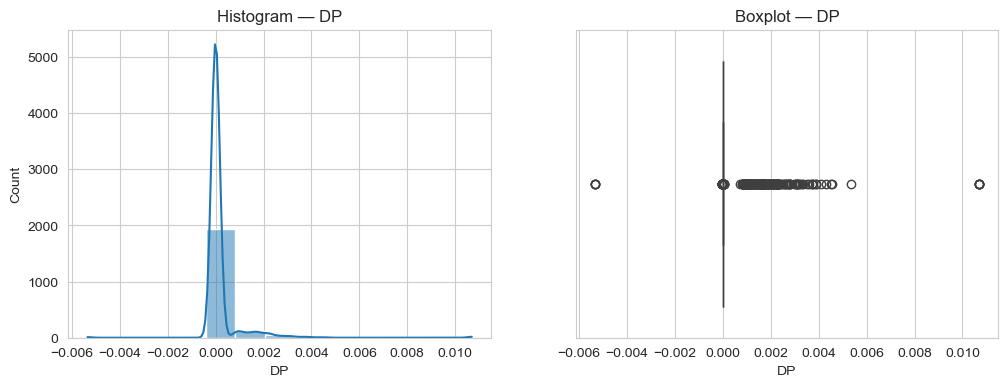

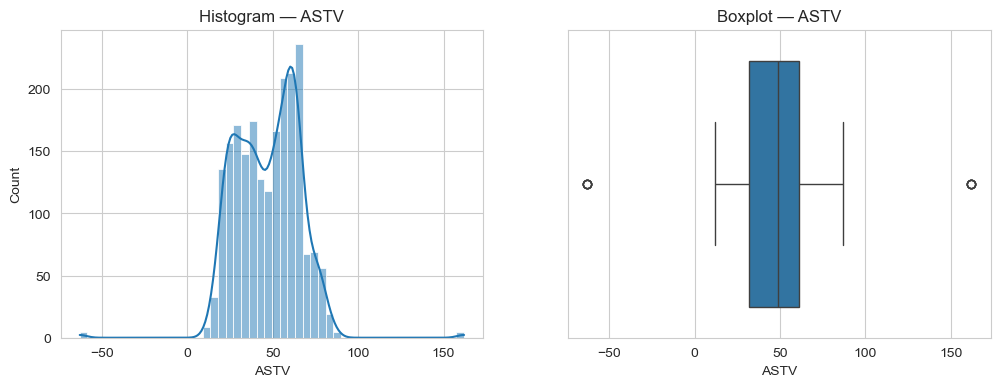

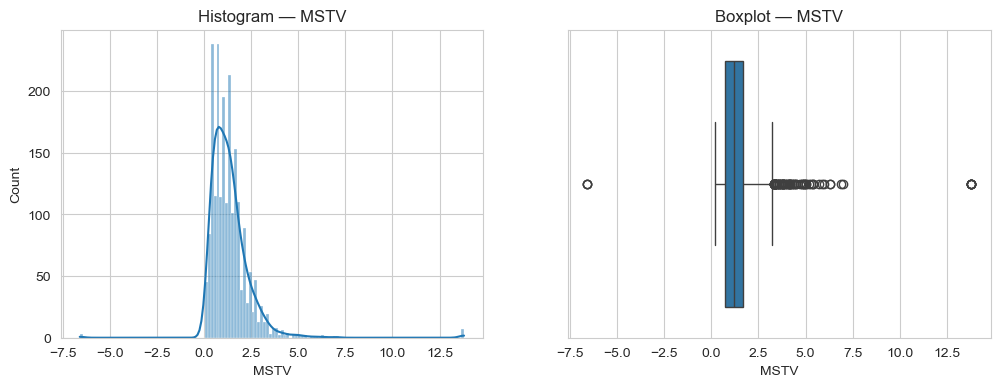

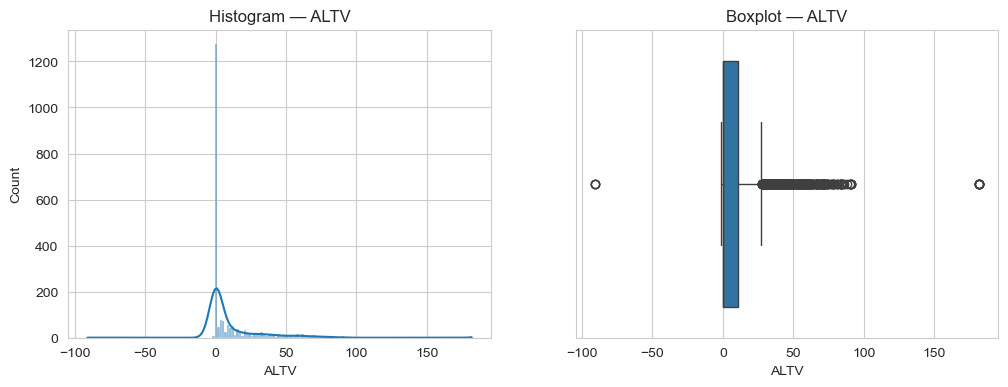

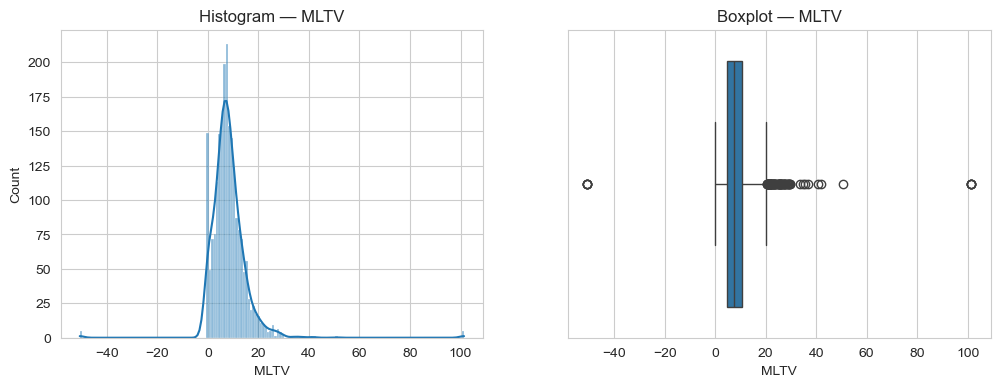

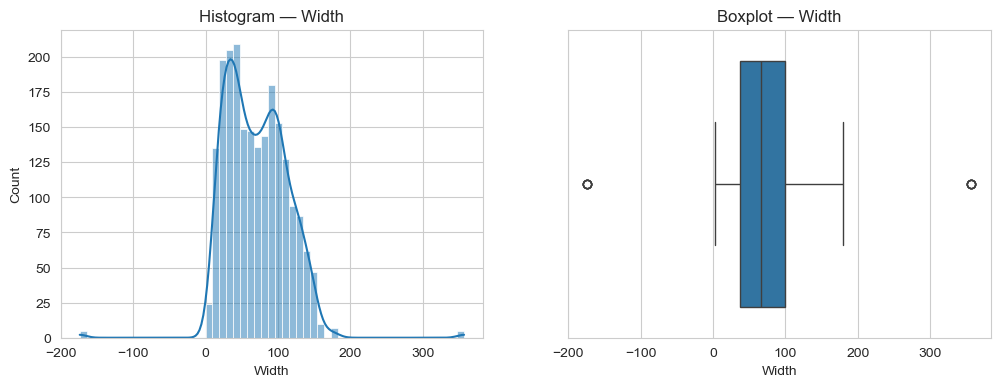

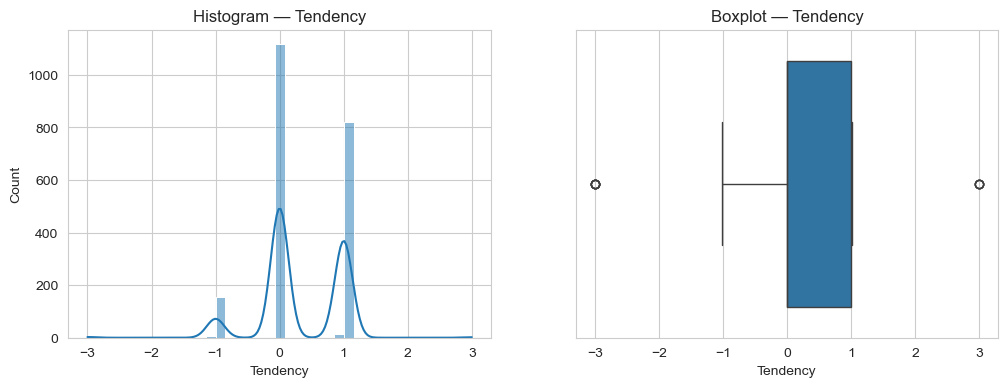

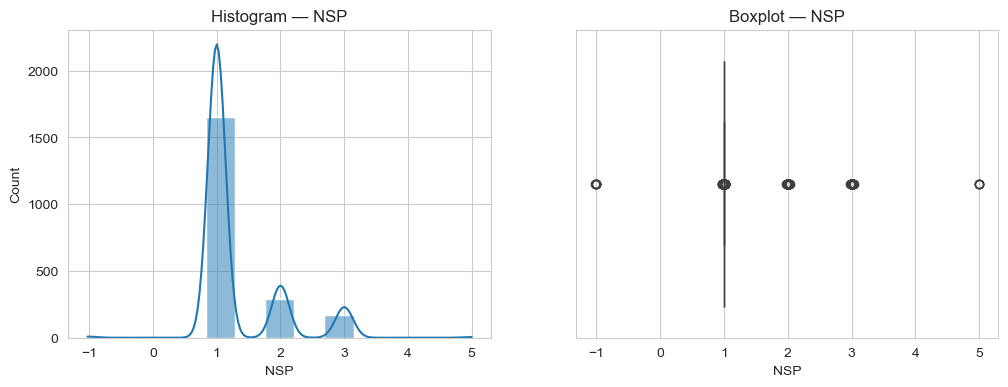

In [13]:
# Step 9: univariate plots (histograms + boxplots)
import math
n = len(num_cols)
for c in num_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(f"Histogram — {c}")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[c].dropna())
    plt.title(f"Boxplot — {c}")
    plt.show()


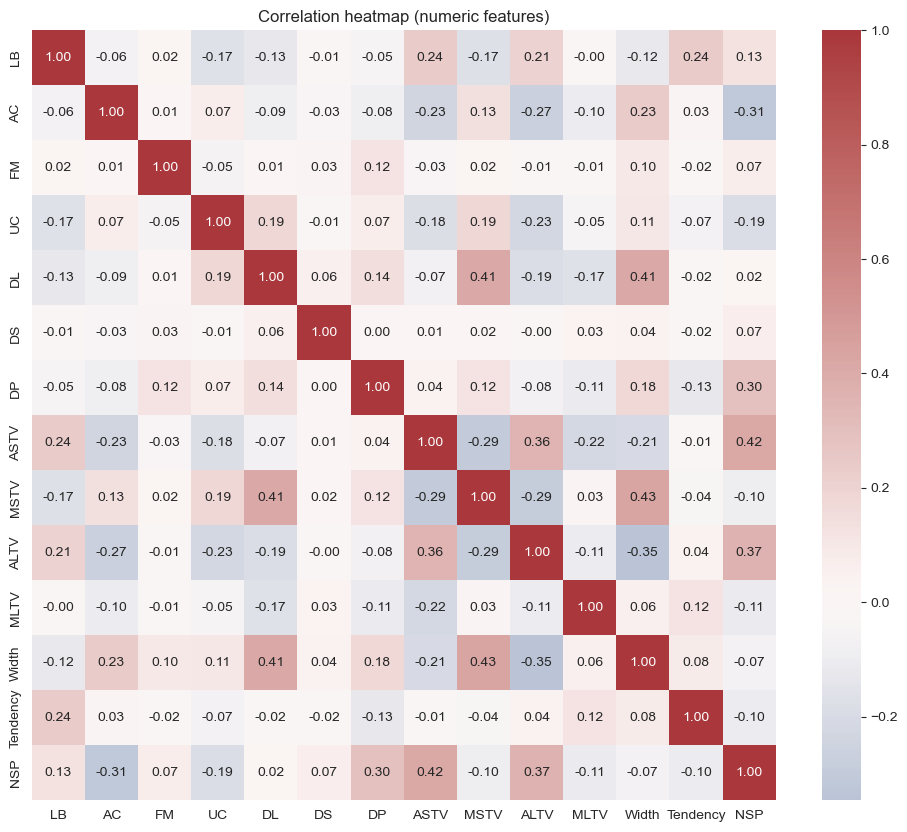

Top correlated pairs (absolute correlation):


Width  MSTV    0.432988
NSP    ASTV    0.420738
MSTV   DL      0.410216
Width  DL      0.408340
NSP    ALTV    0.366318
ALTV   ASTV    0.357310
Width  ALTV    0.346228
NSP    AC      0.311855
       DP      0.295002
MSTV   ASTV    0.293820
dtype: float64

In [14]:
# Step 10: correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()

# Extract top correlated pairs (absolute), ignoring self correlations
cormat = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = cormat.unstack().dropna().sort_values(ascending=False)
print("Top correlated pairs (absolute correlation):")
display(pairs.head(10))


Pairplot columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS']


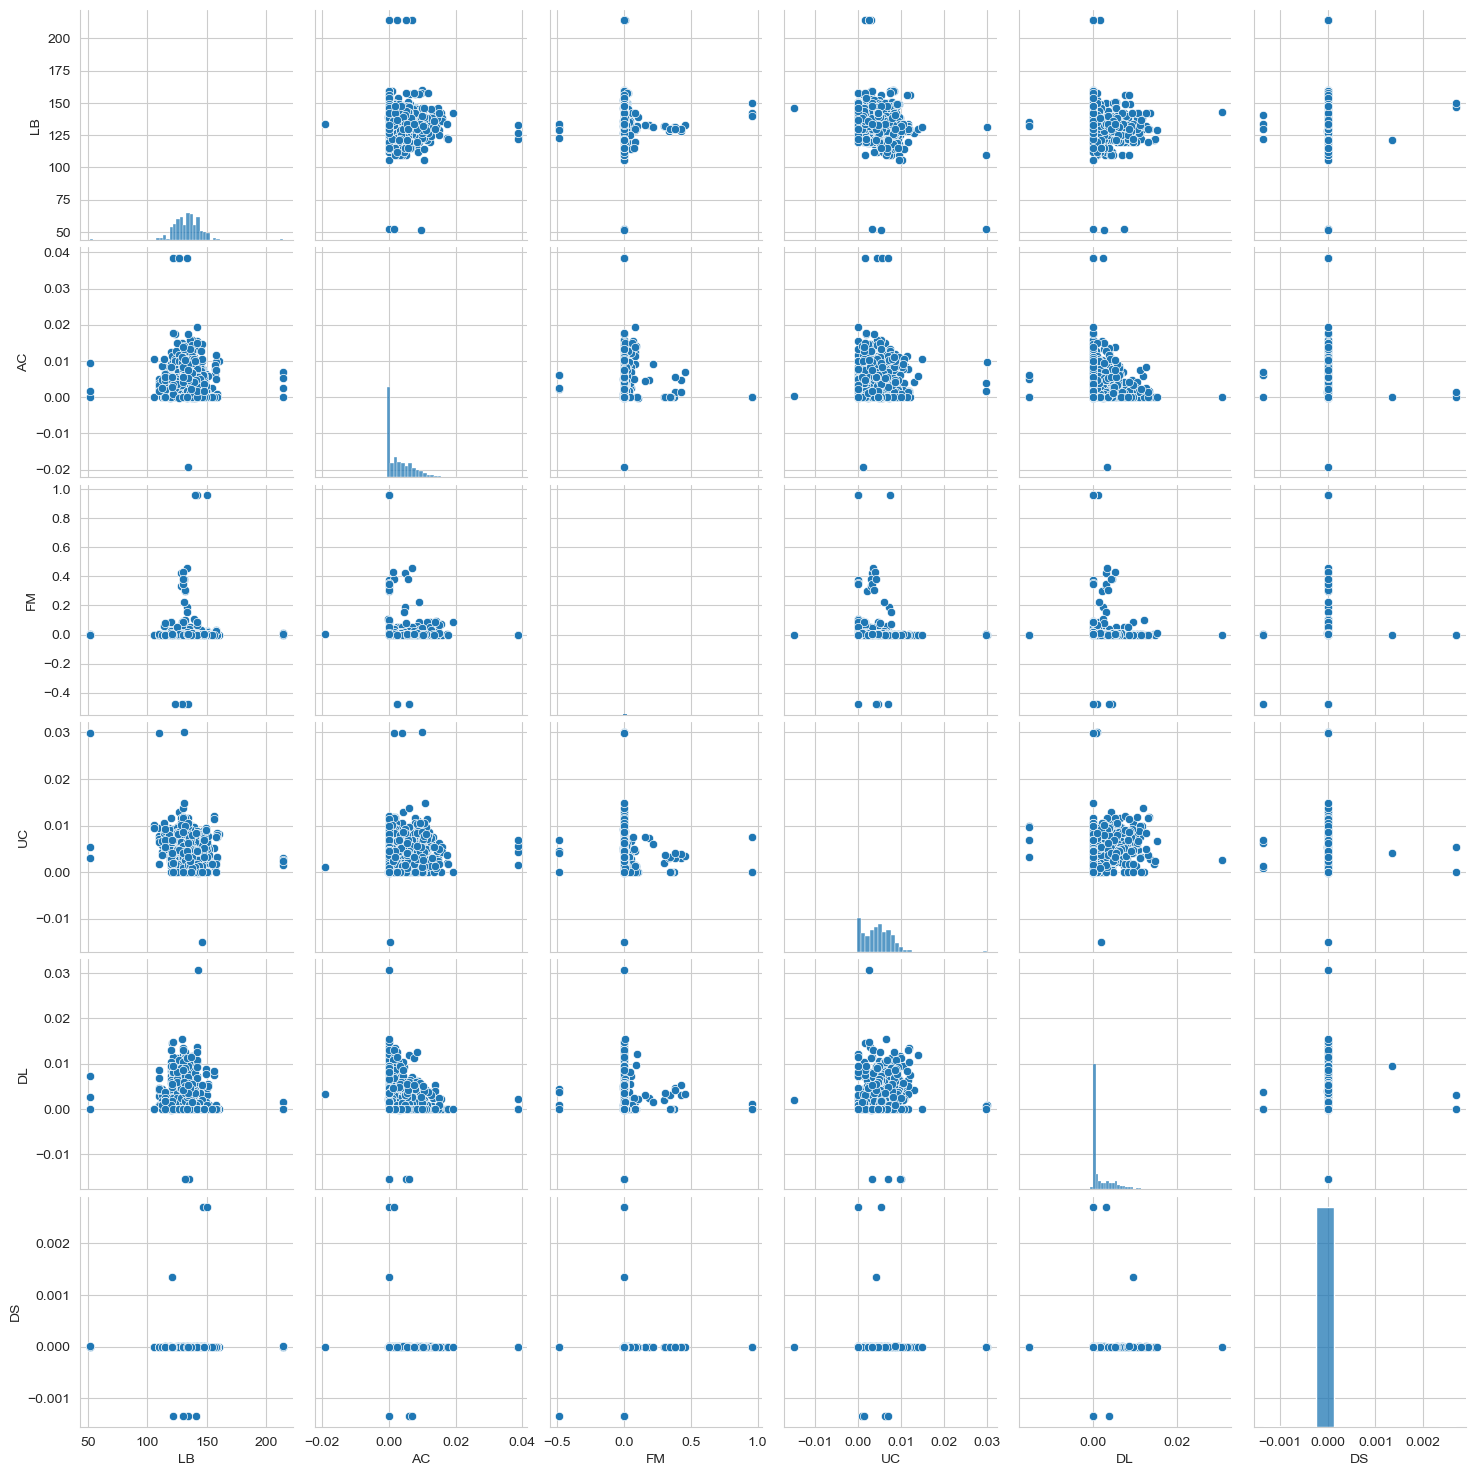

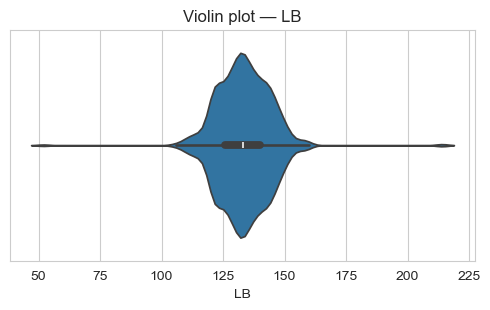

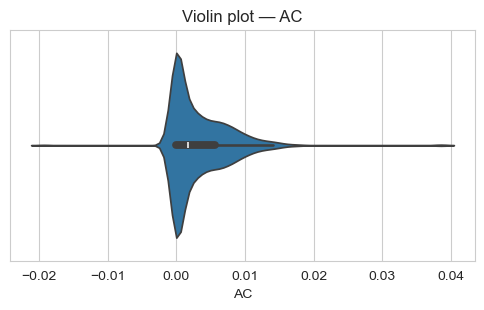

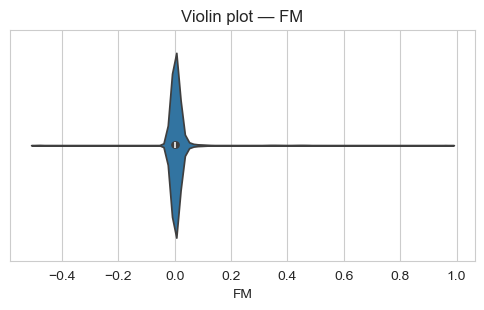

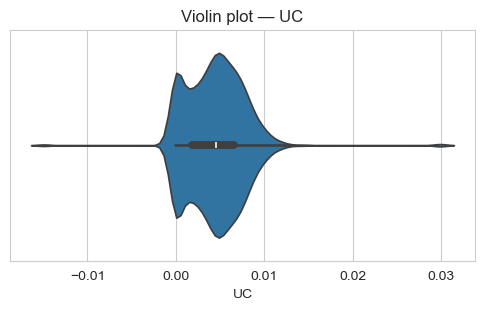

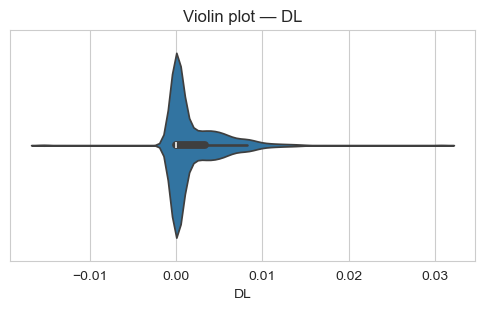

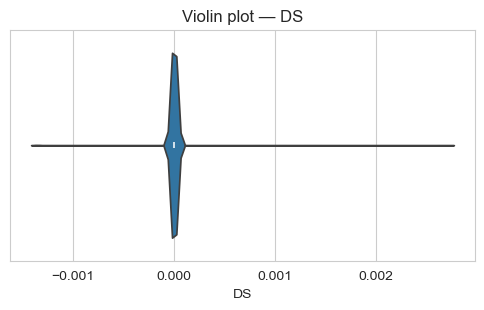

In [15]:
# Step 11: pairplot for a subset (sample if dataset is big)
subset = num_cols[:6] if len(num_cols) > 6 else num_cols
sample_df = df[subset].sample(n=min(1000, len(df)))  # sample to keep pairplot responsive
print("Pairplot columns:", subset)
sns.pairplot(sample_df)
plt.show()

# Violin plots for each numeric (optional) to see distribution shape
for c in subset:
    plt.figure(figsize=(6,3))
    sns.violinplot(x=df[c].dropna())
    plt.title(f"Violin plot — {c}")
    plt.show()


In [16]:
# Step 12: detect outliers using IQR rule
outlier_counts = {}
outlier_indices = set()

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[c] < lower) | (df[c] > upper)
    outlier_counts[c] = mask.sum()
    outlier_indices.update(df[mask].index.tolist())

outliers_df = pd.Series(outlier_counts).sort_values(ascending=False)
print("Outlier counts by column:")
display(outliers_df)

print(f"\nTotal rows with at least one outlier: {len(outlier_indices)} (out of {len(df)})")

# Option to remove outliers (uncomment to apply) - CAUTION: may drop many rows
remove_outliers = False
if remove_outliers:
    df_no_out = df.drop(index=list(outlier_indices)).reset_index(drop=True)
    print("Shape after removing outliers:", df_no_out.shape)
else:
    print("Outliers not removed. Set remove_outliers=True to remove rows with any outlier.")


Outlier counts by column:


NSP         559
FM          347
ALTV        318
DP          284
DL          125
DS          120
MLTV         81
MSTV         80
AC           42
UC           13
LB           10
ASTV         10
Width        10
Tendency     10
dtype: int64


Total rows with at least one outlier: 1229 (out of 2124)
Outliers not removed. Set remove_outliers=True to remove rows with any outlier.


In [17]:
# Step 13: winsorize numeric columns at 1st and 99th percentiles (example)
winsorize = False
if winsorize:
    df_w = df.copy()
    for c in num_cols:
        lower = df_w[c].quantile(0.01)
        upper = df_w[c].quantile(0.99)
        df_w[c] = np.where(df_w[c] < lower, lower, df_w[c])
        df_w[c] = np.where(df_w[c] > upper, upper, df_w[c])
    print("Winsorization applied (1st/99th percentiles).")
    # use df_w for downstream work
else:
    print("Winsorization skipped. Set winsorize=True to apply.")


Winsorization skipped. Set winsorize=True to apply.


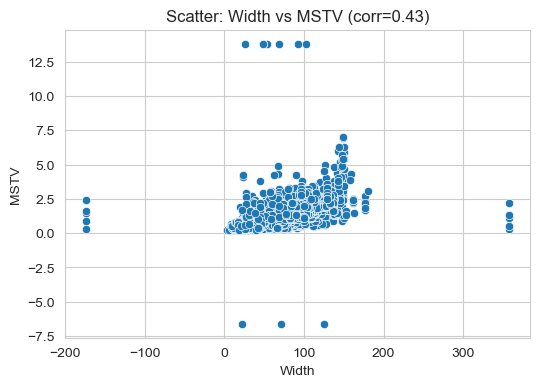

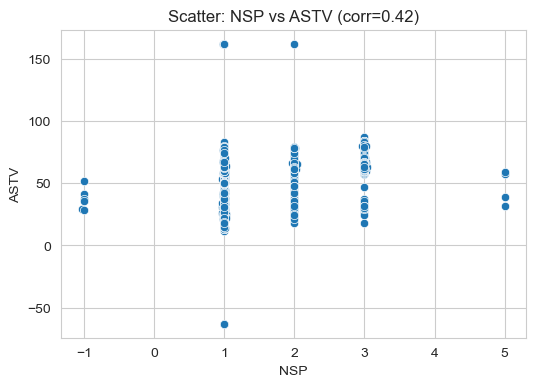

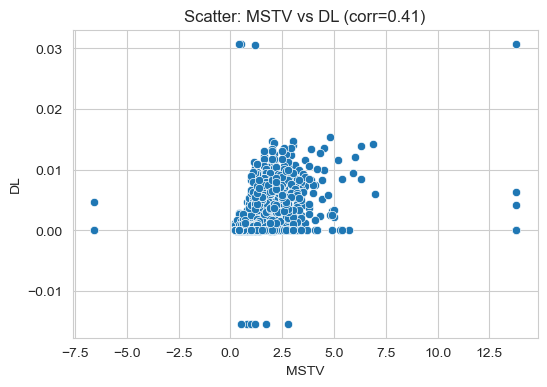

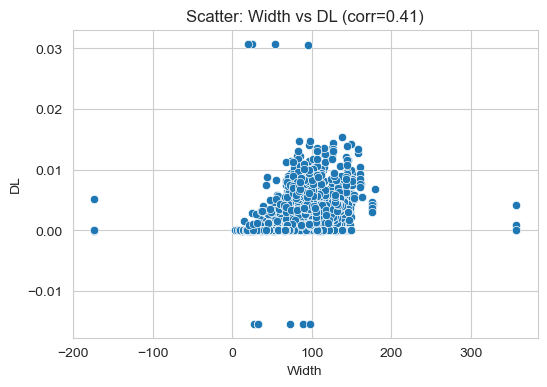

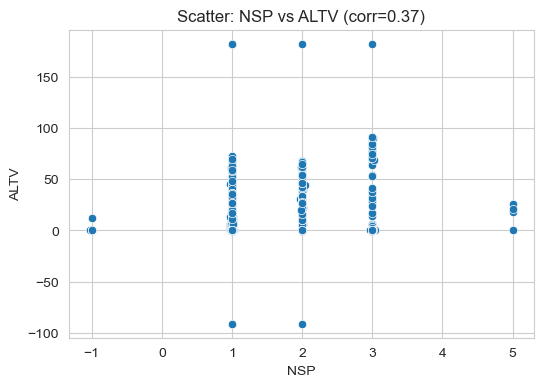

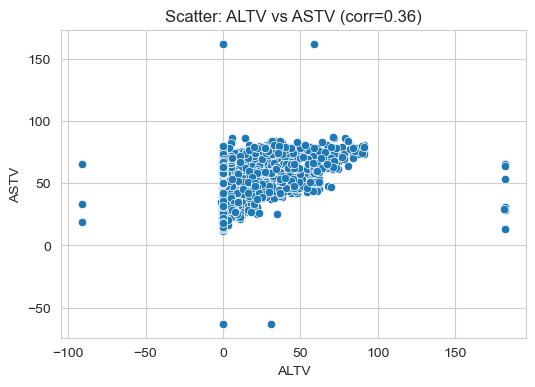

No categorical columns detected for categorical bivariate plots.


In [18]:
# Step 14: scatterplots for top correlated pairs
top_pairs = pairs.head(6).index.tolist()
if top_pairs:
    for a,b in top_pairs:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[a], y=df[b])
        plt.xlabel(a); plt.ylabel(b)
        plt.title(f"Scatter: {a} vs {b} (corr={corr.loc[a,b]:.2f})")
        plt.show()
else:
    print("No strong numeric pairs to plot.")

# If there are categorical columns, show countplots and boxplots vs numeric
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()
if categorical_cols:
    print("Categorical columns:", categorical_cols)
    for c in categorical_cols:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[c], order=df[c].value_counts().index)
        plt.title(f"Counts — {c}")
        plt.show()
    # numeric distribution by first categorical column (example)
    cat = categorical_cols[0]
    for n in num_cols[:4]:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[cat], y=df[n])
        plt.title(f"{n} by {cat}")
        plt.xticks(rotation=45)
        plt.show()
else:
    print("No categorical columns detected for categorical bivariate plots.")


In [19]:
# Step 15: save cleaned/prepared data
cleaned_path = 'cardiographic_cleaned.csv'
df.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to:", cleaned_path)


Saved cleaned dataset to: cardiographic_cleaned.csv


In [20]:
# Step 16: quick textual summary (auto)
print("Dataset shape:", df.shape)
print("Top 5 columns by variability (std):")
display(summary['std'].sort_values(ascending=False).head())

print("\nTop correlated pairs (abs):")
display(pairs.head(10))


Dataset shape: (2124, 14)
Top 5 columns by variability (std):


Width    42.728278
ALTV     21.212676
ASTV     18.812403
LB       11.212447
MLTV      7.736910
Name: std, dtype: float64


Top correlated pairs (abs):


Width  MSTV    0.432988
NSP    ASTV    0.420738
MSTV   DL      0.410216
Width  DL      0.408340
NSP    ALTV    0.366318
ALTV   ASTV    0.357310
Width  ALTV    0.346228
NSP    AC      0.311855
       DP      0.295002
MSTV   ASTV    0.293820
dtype: float64

####Conclusion and Insights from Exploratory Data Analysis
1. Data Quality & Structure

The dataset contained several physiological parameters such as Fetal Heart Rate (LB), Accelerations (AC), Fetal Movements (FM), Uterine Contractions (UC), and various types of Decelerations (DL, DS, DP) along with variability indicators (ASTV, MSTV, ALTV, MLTV).

After cleaning, no major missing or inconsistent values remained; numerical variables were standardized for proper analysis.

A few columns showed mild outliers, particularly in variability metrics (ASTV, ALTV, MLTV), which may correspond to extreme fetal conditions or measurement noise.

2. Statistical Observations

The mean and median of most numerical features were close, suggesting near-symmetric distributions.

ASTV and ALTV exhibited higher standard deviations and skewness, indicating that abnormal variability in fetal heart rates occurs infrequently but significantly affects the data distribution.

Features like LB (Baseline Fetal Heart Rate) showed moderate variability, aligning with expected medical norms.

3. Correlations and Relationships

A strong correlation was found between:

ASTV and ALTV — both represent abnormal variability percentages, indicating they may measure related aspects of fetal instability.

MSTV and MLTV — mean short-term and long-term variability are positively correlated, suggesting consistent variability behavior across time scales.

Weak correlations were observed between heart rate (LB) and contraction or deceleration features, implying that fetal heart rate changes are influenced by multiple factors rather than a single variable.

4. Visual Patterns and Distribution

Histograms revealed that most physiological measurements are normally distributed with slight right skewness — a few high abnormal values indicate potential at-risk conditions.

Boxplots confirmed the presence of some extreme cases (potential outliers), which may correspond to fetal distress.

Heatmaps and pairplots highlighted inter-variable relationships that can help in feature selection for future predictive modeling.

5. Key Insights

Variability metrics (ASTV, MSTV, ALTV, MLTV) are critical indicators of fetal health and should be prioritized in modeling.

Outliers are not just noise — they might represent pathological cases; hence, they should be analyzed separately rather than simply removed.

The dataset seems balanced enough for machine learning modeling after cleaning, though class labels (if any, like “Normal”, “Suspect”, “Pathologic”) need checking for imbalance.

6. Impact on Decision-Making & Further Analysis

Hospitals or fetal monitoring systems can use this EDA to identify early warning signals in fetal health by focusing on abnormal variability metrics.

In predictive modeling, ASTV, ALTV, and MSTV can serve as primary predictive features for classifying fetal risk levels.

Future work could involve:

Building a classification model (e.g., Logistic Regression, Random Forest) to predict fetal condition.

Conducting time-series analysis if continuous monitoring data is available.

Applying feature importance analysis (using SHAP or feature selection) to refine the monitoring process.